# 🌾 Precision Agriculture & Crop Intelligence
## Arab 813 Hackathon — Planet Tanager Hyperspectral Explorer

Welcome! This notebook guides you through using **Planet's Tanager hyperspectral satellite** to analyse **crop health and soil conditions** — with 426 spectral bands ranging from 400 nm to 2,500 nm, far beyond what the human eye can see.

---

## What You Will Learn

- How hyperspectral imagery differs from ordinary RGB satellite images
- How to query Planet's open STAC catalog for agricultural scenes
- How to download and explore a Tanager HDF5 scene
- How to compute agriculture-specific spectral indices:
  - **NDVI** — vegetation greenness and photosynthetic activity
  - **NDRE** — plant nitrogen / chlorophyll stress (red-edge)
  - **NDMI** — moisture stress / irrigation status
  - **BSI** — bare soil index

---

## Why Hyperspectral for Agriculture?

An ordinary satellite photograph records only red, green, and blue light — essentially what your phone camera sees. Tanager records **426 narrow spectral bands**, which means it can detect:

- **Chlorophyll content** → early stress before visible wilting
- **Leaf water content** → irrigation deficits
- **Soil organic matter** → fertility mapping
- **Crop type discrimination** → different plants reflect light differently

This is the same technology used by NASA scientists to monitor ecosystems from space.

---

## Relevant STAC Collection

```
https://www.planet.com/data/stac/tanager-core-imagery/agriculture/collection.json
```


In [8]:
%pip install pystac-client planetary-computer stackstac rasterio xarray matplotlib geopandas leafmap ipywidgets rioxarray h5py requests

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [9]:
import os
# Reset leafmap titiler endpoint to the public instance.
# This prevents errors if Planetary Computer cells ran earlier in the session.
os.environ["TITILER_ENDPOINT"] = "https://titiler.xyz"

## Step 1 – Load Items from the Agriculture Collection

We load STAC items directly from Planet's open data server.
Each **item** is one satellite scene — a strip of imagery roughly 18 km wide.

> 💡 **Tip:** Browse the full list of available scenes at:
> https://www.planet.com/data/stac/browser/tanager-core-imagery/agriculture/collection.json


In [10]:
import requests

COLLECTION = "agriculture"
#item_ids = ["20250305_053421_32_4001", "20250311_061550_53_4001", "20250321_054913_40_4001"]
item_ids = ["20250608_091605_90_4001","20250331_113403_16_4001","20250407_035527_47_4001"]

base = f"https://www.planet.com/data/stac/tanager-core-imagery/{COLLECTION}"
items = []
for iid in item_ids:
    url = f"{base}/{iid}/{iid}.json"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    items.append(r.json())
print(f"Loaded {len(items)} items from {COLLECTION}")

item = items[0]   # work with the first scene

Loaded 3 items from agriculture


## Step 2 – Inspect Scene Metadata

Every STAC item carries rich metadata: acquisition time, sensor geometry, cloud cover, and more.
Understanding your scene before downloading data saves time.


In [11]:
from IPython.display import Image
print("Scene ID:", item["id"])
print("Date    :", item["properties"]["datetime"])
print("Bbox    :", item["bbox"])
Image(url=item["assets"]["thumbnail"]["href"])

Scene ID: 20250608_091605_90_4001
Date    : 2025-06-08T09:16:05.903891Z
Bbox    : [32.44227196464563, 37.51375341016496, 32.70580618046614, 37.69491765950834]


In [12]:
import json
print(json.dumps(item["properties"], indent=2))

{
  "cloud_percent": 2,
  "collection_mode": "standard_sensitivity",
  "constellation": "Tanager",
  "datetime": "2025-06-08T09:16:05.903891Z",
  "description": "All data products from Tanager-1 for 20250608_091605_90_4001 near \u00c7umra, Konya, Central Anatolia Region, 42500, Turkey",
  "gsd": 32.72,
  "instruments": [
    "4001"
  ],
  "license": "CC-BY-4.0",
  "light_haze_percent": 0,
  "location_description": "\u00c7umra, Konya, Central Anatolia Region, 42500, Turkey",
  "notes": null,
  "platform": "Planet",
  "plume_provider_ids": null,
  "quality_category": "standard",
  "title": "TanagerScene 20250608_091605_90_4001 Core Imagery",
  "view:azimuth": 113,
  "view:off_nadir": 5.8,
  "view:sun_azimuth": 152.2,
  "view:sun_elevation": 73.7
}


## Step 3 – Visualize the Scene on a Map

We overlay the visual (RGB) COG on an interactive map so you can see exactly where this image is.


In [13]:
import leafmap, geopandas as gpd
from shapely.geometry import box

m = leafmap.Map(zoom=8)
ib = item["bbox"]
m.fit_bounds([[ib[1], ib[0]], [ib[3], ib[2]]])

# Scene footprint
gdf = gpd.GeoDataFrame({"geometry": [box(*ib)]}, crs="EPSG:4326")
m.add_gdf(gdf, layer_name="Scene footprint", style={"color":"yellow","fillOpacity":0})

# Visual COG overlay
for vk in ["ortho_visual", "visual", "rendered_preview"]:
    if vk in item.get("assets", {}):
        m.add_cog_layer(item["assets"][vk]["href"],
                        name=item["id"]+" (visual)",
                        titiler_endpoint="https://titiler.xyz")
        break

m

Map(center=[32.57374679590245, 37.60428938558967], controls=(ZoomControl(options=['position', 'zoom_in_text', …

## Step 4 – Download the Surface Reflectance HDF5

The HDF5 file contains all 426 bands of atmospherically-corrected **surface reflectance** — the fraction of sunlight reflected by the ground.
Surface reflectance is the right product for vegetation and soil indices because the atmosphere has already been removed.

> ⏳ Download may take several minutes depending on your connection speed.


In [14]:
import os, requests

sr_key = "ortho_sr_hdf5" if "ortho_sr_hdf5" in item["assets"] else "basic_sr_hdf5"
sr_url = item["assets"][sr_key]["href"]
print("Using SR asset:", sr_key)
print("URL:", sr_url)

local_path = os.path.basename(sr_url)
if not os.path.exists(local_path):
    print("Downloading… (may take a few minutes)")
    with requests.get(sr_url, stream=True) as r:
        r.raise_for_status()
        with open(local_path, "wb") as fout:
            for chunk in r.iter_content(chunk_size=1024*1024):
                if chunk:
                    fout.write(chunk)
    print("Saved to:", local_path)
else:
    print("Already downloaded:", local_path)

Using SR asset: ortho_sr_hdf5
URL: https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/ortho_sr_hdf5/20250608_091605_90_4001_ortho_sr_hdf5.h5
Downloading… (may take a few minutes)
Saved to: 20250608_091605_90_4001_ortho_sr_hdf5.h5


## Step 5 – Check Scene Quality

Before computing indices, we check how much of the scene is valid (not cloud-covered or missing).


In [15]:
import h5py, numpy as np

root = "HDFEOS/GRIDS/HYP/Data Fields"
with h5py.File(local_path, "r") as f:
    cloud  = f[f"{root}/beta_cloud_mask"][:]
    nodata = f[f"{root}/nodata_pixels"][:]
    cirrus = f[f"{root}/beta_cirrus_mask"][:]

valid = (nodata == 0) & (cloud == 0) & (cirrus == 0)
print(f"Valid pixels: {valid.mean()*100:.1f}%")
print(f"Cloud cover:  {(cloud!=0).mean()*100:.1f}%")

Valid pixels: 68.7%
Cloud cover:  1.1%


## Step 6 – Extract Spectral Wavelengths

Tanager's 426 bands are not evenly spaced across a round number — they are calibrated physical measurements.
We read the exact center wavelength of every band from the STAC metadata.


In [16]:
# Extract spectral wavelengths from STAC metadata.
# The key is "bands" and wavelengths are in micrometers under "eo:center_wavelength".
bands_meta = item["assets"][sr_key].get("bands", [])
spectral_bands = [b for b in bands_meta if "eo:center_wavelength" in b]
wavelengths_um = np.array([b["eo:center_wavelength"] for b in spectral_bands], dtype=float)
wavelengths_nm = wavelengths_um * 1000.0   # micrometers -> nanometers

print("Number of spectral bands:", len(wavelengths_nm))
print("First 10 wavelengths (nm):", np.round(wavelengths_nm[:10], 2))
print("Last  10 wavelengths (nm):", np.round(wavelengths_nm[-10:], 2))

Number of spectral bands: 426
First 10 wavelengths (nm): [376.44 381.41 386.38 391.35 396.32 401.29 406.26 411.23 416.21 421.18]
Last  10 wavelengths (nm): [2454.39 2459.35 2464.31 2469.26 2474.22 2479.18 2484.13 2489.09 2494.04
 2499.  ]


## Step 7 – Select Key Agricultural Wavelengths

Agriculture indices use carefully chosen wavelengths. We pick the Tanager band nearest each target.

| Index | Wavelengths Used | What It Measures |
|-------|-----------------|-----------------|
| NDVI  | 665 nm (Red), 860 nm (NIR) | General vegetation greenness |
| NDRE  | 665 nm (Red), 705 nm (Red-Edge) | Chlorophyll / nitrogen stress |
| NDMI  | 860 nm (NIR), 1650 nm (SWIR) | Leaf water / moisture stress |
| BSI   | 1600 nm (SWIR), 830 nm (NIR), 680 nm (Red), 570 nm (Green) | Bare soil exposure |


In [17]:
import numpy as np
def pick_band(target_nm):
    idx = int(np.argmin(np.abs(wavelengths_nm - target_nm)))
    print(f"  Target {target_nm} nm → band {idx} ({wavelengths_nm[idx]:.1f} nm)")
    return idx, wavelengths_nm[idx]

print("Selecting bands:")
idx_green, _ = pick_band(570)
idx_red,   _ = pick_band(665)
idx_re,    _ = pick_band(705)
idx_nir,   _ = pick_band(860)
idx_swir,  _ = pick_band(1650)

Selecting bands:
  Target 570 nm → band 39 (570.8 nm)
  Target 665 nm → band 58 (665.9 nm)
  Target 705 nm → band 66 (705.9 nm)
  Target 860 nm → band 97 (861.3 nm)
  Target 1650 nm → band 254 (1647.7 nm)


## Step 8 – Load the Required Bands

We only read the 5 bands we need from the HDF5 file instead of the full 426-band cube.
This is much faster and uses less memory.


In [18]:
import h5py

root = "HDFEOS/GRIDS/HYP/Data Fields"

with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    R_green = sr[idx_green, :, :].astype("float32")
    R_red   = sr[idx_red,   :, :].astype("float32")
    R_re    = sr[idx_re,    :, :].astype("float32")
    R_nir   = sr[idx_nir,   :, :].astype("float32")
    R_swir  = sr[idx_swir,  :, :].astype("float32")

# Mask invalid/cloudy pixels
for arr in [R_green, R_red, R_re, R_nir, R_swir]:
    arr[~valid] = np.nan
    arr[arr < 0] = np.nan

print("Bands loaded. Scene size:", R_red.shape)

Bands loaded. Scene size: (673, 776)


## Step 9 – Compute Spectral Indices

### NDVI — Normalized Difference Vegetation Index
**Formula:** `(NIR - Red) / (NIR + Red)`

Ranges from −1 to +1. Healthy crops → 0.4–0.9. Bare soil → 0.0–0.2. Water → negative.


In [19]:
eps = 1e-6
NDVI = (R_nir - R_red)  / (R_nir + R_red  + eps)

### NDRE — Normalized Difference Red Edge
**Formula:** `(NIR - RedEdge) / (NIR + RedEdge)`

More sensitive than NDVI to early stress and nitrogen deficiency — plants show red-edge changes before visibly wilting.


In [20]:
NDRE = (R_nir - R_re) / (R_nir + R_re + eps)

### NDMI — Normalized Difference Moisture Index
**Formula:** `(NIR - SWIR) / (NIR + SWIR)`

Tracks water content inside leaves. Used for irrigation monitoring and drought stress mapping.


In [21]:
NDMI = (R_nir - R_swir) / (R_nir + R_swir + eps)

### BSI — Bare Soil Index
**Formula:** `((SWIR + Red) - (NIR + Green)) / ((SWIR + Red) + (NIR + Green))`

Highlights exposed soil. High BSI → fallow or harvested fields. Low BSI → vegetated land.


In [22]:
BSI = ((R_swir + R_red) - (R_nir + R_green)) / ((R_swir + R_red) + (R_nir + R_green) + eps)

## Step 10 – Visualize the Indices

Four panels show crop conditions across the scene.
Use these maps to identify:
- Where crops are healthy vs stressed (NDVI, NDRE)
- Which fields may need irrigation (NDMI)
- Which areas are bare soil vs crop-covered (BSI)


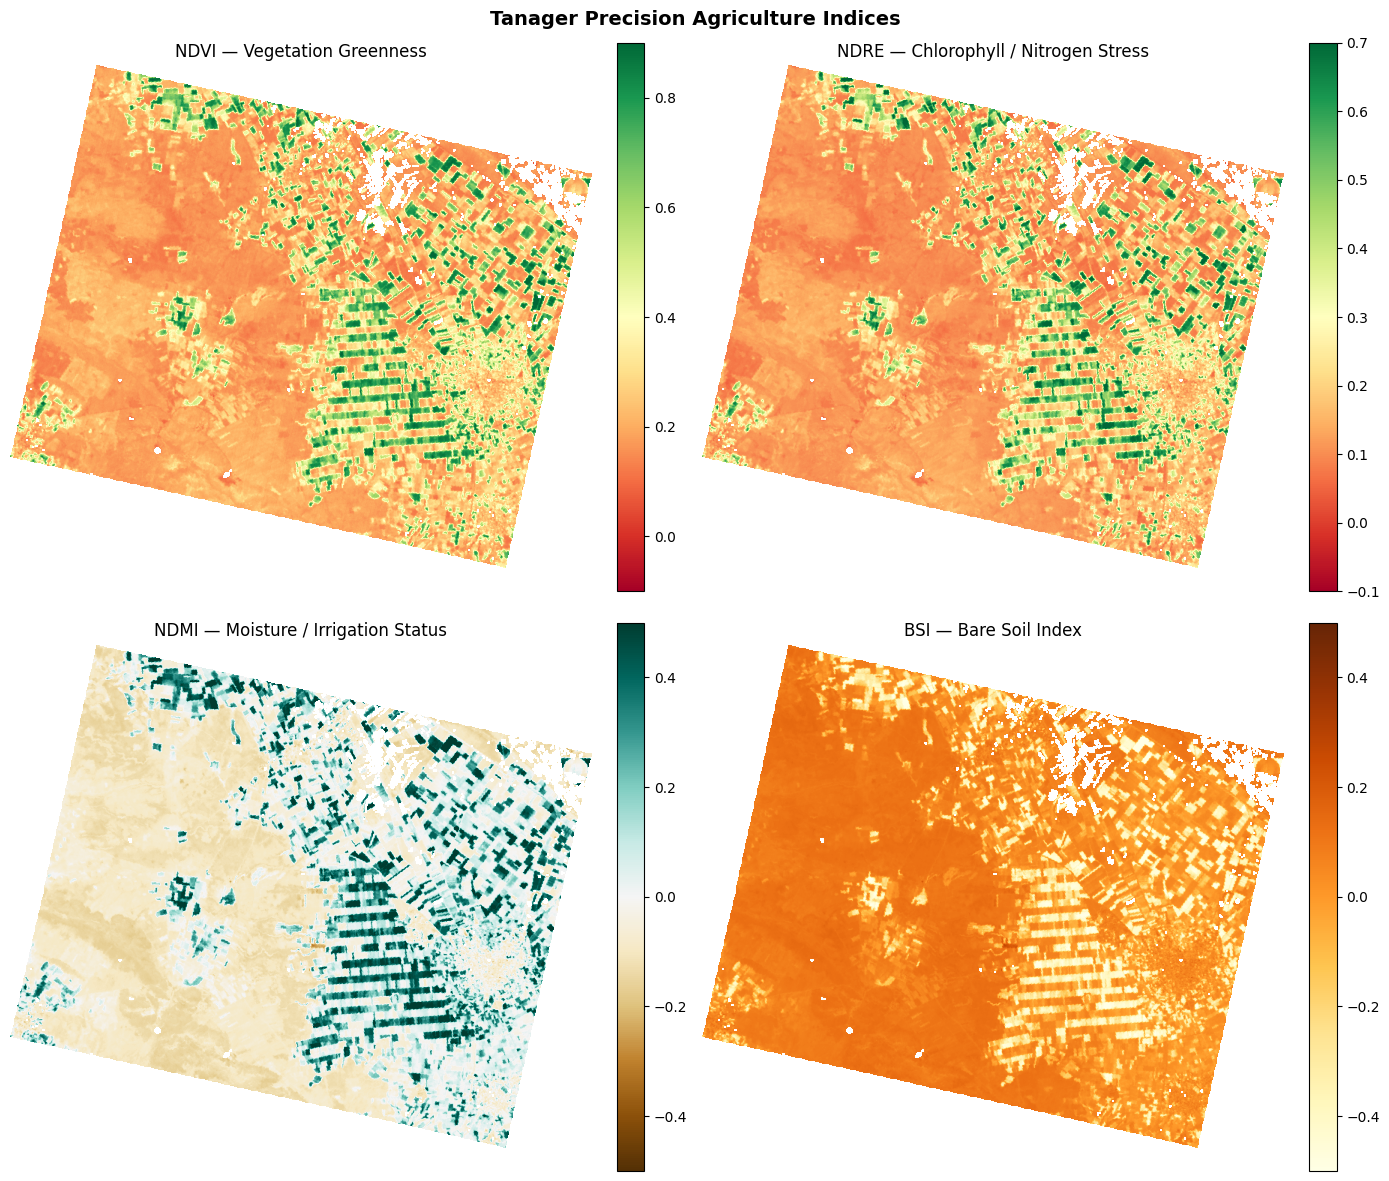

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

im1 = axes[0,0].imshow(NDVI, cmap="RdYlGn", vmin=-0.1, vmax=0.9)
axes[0,0].set_title("NDVI — Vegetation Greenness"); axes[0,0].axis("off")
plt.colorbar(im1, ax=axes[0,0], fraction=0.046, pad=0.04)

im2 = axes[0,1].imshow(NDRE, cmap="RdYlGn", vmin=-0.1, vmax=0.7)
axes[0,1].set_title("NDRE — Chlorophyll / Nitrogen Stress"); axes[0,1].axis("off")
plt.colorbar(im2, ax=axes[0,1], fraction=0.046, pad=0.04)

im3 = axes[1,0].imshow(NDMI, cmap="BrBG", vmin=-0.5, vmax=0.5)
axes[1,0].set_title("NDMI — Moisture / Irrigation Status"); axes[1,0].axis("off")
plt.colorbar(im3, ax=axes[1,0], fraction=0.046, pad=0.04)

im4 = axes[1,1].imshow(BSI, cmap="YlOrBr", vmin=-0.5, vmax=0.5)
axes[1,1].set_title("BSI — Bare Soil Index"); axes[1,1].axis("off")
plt.colorbar(im4, ax=axes[1,1], fraction=0.046, pad=0.04)

plt.suptitle("Tanager Precision Agriculture Indices", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## Step 11 – Summary Statistics


In [24]:
def summarize(name, arr):
    print(f"{name}:")
    print(f"  min={np.nanmin(arr):.3f}  max={np.nanmax(arr):.3f}  mean={np.nanmean(arr):.3f}  std={np.nanstd(arr):.3f}")

summarize("NDVI",  NDVI)
summarize("NDRE",  NDRE)
summarize("NDMI",  NDMI)
summarize("BSI",   BSI)

NDVI:
  min=0.037  max=0.923  mean=0.289  std=0.183
NDRE:
  min=0.008  max=0.762  mean=0.193  std=0.143
NDMI:
  min=-0.308  max=0.647  mean=0.013  std=0.166
BSI:
  min=-0.597  max=0.271  mean=0.008  std=0.148


## Step 12 – Mean Spectral Signature

The spectral signature is a **fingerprint** of the average surface in the scene.
Different land cover types (crops, soil, water) have characteristic shapes in this plot.


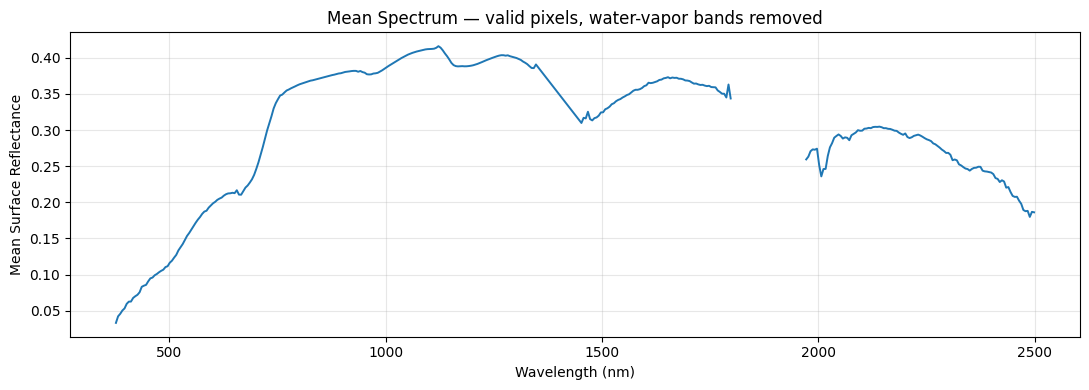

In [25]:
def is_water_vapor(wl):
    return (1350 <= wl <= 1450) or (1800 <= wl <= 1950)

stride = 8
with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    good_idx = [i for i, w in enumerate(wavelengths_nm) if not is_water_vapor(w)]
    cube = sr[good_idx, ::stride, ::stride].astype("float32")
    mask = valid[::stride, ::stride]
    cube[:, ~mask] = np.nan
    cube[cube < 0] = np.nan
    mean_spec = np.nanmean(cube, axis=(1,2))

import matplotlib.pyplot as plt
wls = [wavelengths_nm[i] for i in good_idx]
plt.figure(figsize=(11,4))
plt.plot(wls, mean_spec, lw=1.4)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Mean Surface Reflectance")
plt.title("Mean Spectrum — valid pixels, water-vapor bands removed")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 🚀 Hackathon Challenge Ideas

### Practical next steps for hackathon projects
- **Field boundary segmentation**: train a U-Net/DeepLab model to delineate fields (labels: digitized polygons).
- **Crop type classification**: use spectral + texture features (or a 1D CNN on spectra) to classify crop types.
- **Irrigation detection**: combine NDMI with weather/soil layers to infer irrigation timing.
- **Yield/stress modeling**: build a regression model using indices + weather + soil; validate with ground points.
- **Active learning**: label a few samples, train, then label the most uncertain pixels next.
- **Crop type mapping** — can you cluster pixels by spectral signature into different crop types?
- **Stress detection** — which fields show low NDRE / NDMI compared to their NDVI?
- **Change detection** — load two scenes from different dates and compare indices.
- **Irrigation efficiency** — rank fields by moisture deficit (NDMI) against their vegetative cover (NDVI).

> 📖 Created by: [LInkedin: Dr. Vincent Markiet - Space42](https://www.linkedin.com/in/vincentmarkiet/) 

> 📖 Data license: CC-BY-4.0 © Planet Labs PBC

